# Song Popularity Prediction — Feature Engineering

**Project 3 · Music Analytics · Laura Blanco**

Based on the findings from the EDA, in this notebook:
1. **The dataset is cleaned and deduplicated** (one row per `track_id`, to prevent *data leakage*).
2. **Derived features** are built (audio interactions, artist prolificness, genre breadth).
3. Binary **target variable** is defined (*hit* = top 25% in popularity).
4. **A sample of artists is enriched using Last.fm** and validated the hypothesis that an artist’s actual popularity is associated with the popularity of their tracks.

> The logic of this notebook resides in reusable modules (`src/features.py`, `src/lastfm_enrich.py`); here is for running and documenting it.
---

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../src").resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import features as F

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 40)
REPORTS = Path("../reports"); REPORTS.mkdir(exist_ok=True)

## 1. Cleaning

Thw whole pipeline is inside `features.build_dataset()`. The step by steps is shown for clarity purposes.

In [2]:
raw = F.load_raw()
print(f"Raw dataset: {raw.shape[0]:,} rows")

clean = F.clean(raw)
print(f"After cleaning nulls: {clean.shape[0]:,} rows")

dedup = F.deduplicate(clean)
print(f"After deduplicating by track_id: {dedup.shape[0]:,} rows "
      f"({clean.shape[0] - dedup.shape[0]:,} duplicates removed)")

Raw dataset: 114,000 rows
After cleaning nulls: 113,999 rows
After deduplicating by track_id: 89,740 rows (24,259 duplicates removed)


The deduplication removes ~24k rows (duplicated tracks due to belonging to different genres). This way every track appears **just once**, which prevents *leakage*.

## 2. Added features and target

In [3]:
df = F.add_features(dedup)
df = F.add_target(df)

nuevas = ["artist_main", "n_genres", "dance_energy", "valence_energy",
          "acoustic_instrumental", "duration_min", "explicit_int",
          "artist_track_count", "is_hit"]
df[["track_name"] + nuevas].head()

,track_name,artist_main,n_genres,dance_energy,valence_energy,acoustic_instrumental,duration_min,explicit_int,artist_track_count,is_hit
0,Mann Mera,Gajendra Verma,2,0.409275,0.285345,0.000000,3.335333,0,3,1
1,Jaan 'Nisaar (Arijit),Arijit Singh,2,0.188552,0.100744,0.000000,3.972817,0,78,1
2,Jhoom - R&B Mix,Ali Zafar,2,0.264800,0.246800,0.000012,4.983100,0,3,1
3,Tum Hi Ho,Arijit Singh,2,0.237072,0.142333,0.000000,4.366233,0,78,1
4,Lover,Diljit Dosanjh,2,0.485449,0.454338,0.000000,3.166667,0,24,1


**New features:**

| Feature | Description | Why? |
|---|---|---|
| `dance_energy` | danceability × energy | Captures the dance-energy merge factor |
| `valence_energy` | valence × energy | Proxy for *mood* (happy+energetic vs sad+calm) |
| `acoustic_instrumental` | acousticness × instrumentalness | Identifies acustic/instrumental material |
| `duration_min` | duration in minutes | Better `duration_ms` read |
| `explicit_int` | explicit as 0/1 | Numeric version |
| `n_genres` | number of genres the song appears in | Gives a vision on how multi-genre the track is |
| `artist_track_count` | number of the artist's songs in the catalog | Proxy for artist's trajectory |

----
> **Metodology side note:** The *target encoding*  features (average genre/artist popularity) **will not** be calculated on this step. They will be included inside cross-validation to avoid filtering important target information.


In [4]:
thr = df.attrs["hit_threshold"]
print(f"Threshold hit (P75): popularity >= {thr:.0f}")
print(f"Hit rate: {df['is_hit'].mean():.1%}")
print(f"\nFinal dimensions: {df.shape}")

Threshold hit (P75): popularity >= 49
Hit rate: 25.1%

Final dimensions: (89740, 29)


## 3. Do the new features segregate hit from no-hits?

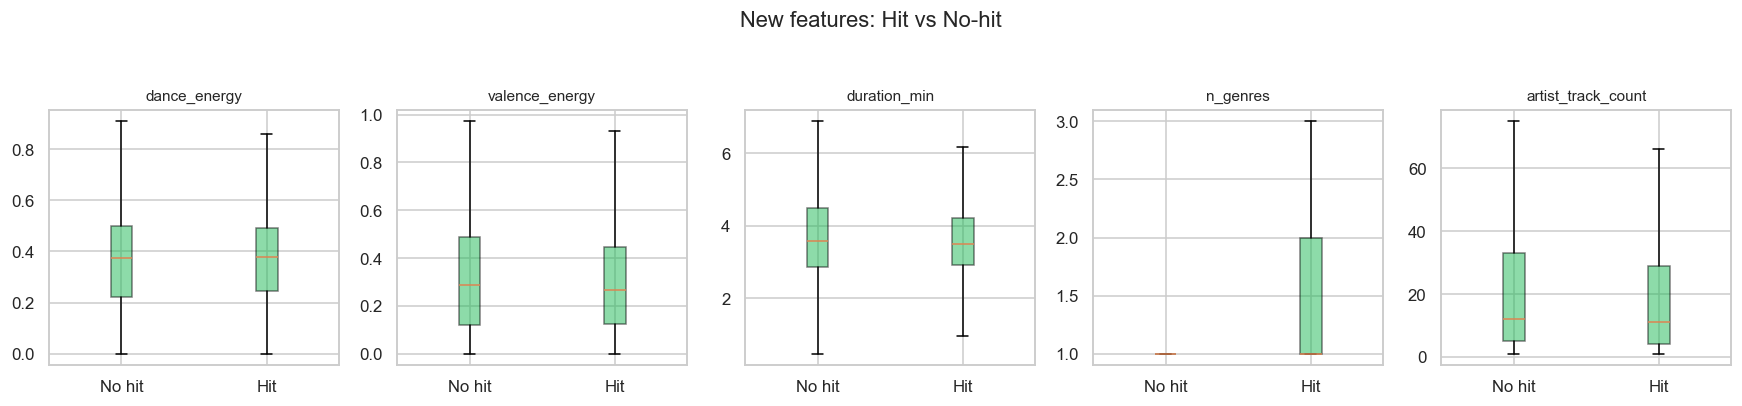

In [5]:
feats_check = ["dance_energy", "valence_energy", "duration_min", "n_genres", "artist_track_count"]
fig, axes = plt.subplots(1, len(feats_check), figsize=(16, 3.5))
for ax, f in zip(axes, feats_check):
    data = [df[df.is_hit == 0][f], df[df.is_hit == 1][f]]
    ax.boxplot(data, labels=["No hit", "Hit"], showfliers=False,
               patch_artist=True,
               boxprops=dict(facecolor="#1DB954", alpha=0.5))
    ax.set_title(f, fontsize=10)
fig.suptitle("New features: Hit vs No-hit", y=1.05)
plt.tight_layout()
plt.savefig(REPORTS / "fig6_derived_features_by_target.png", bbox_inches="tight")
plt.show()

`n_genres` shows the most clear difference: **genre mixture gets a hit** on most of the cases. The other feature interactions are not as revealing, but will be make a good use on non-lineal modeling.

## 4. Enriching dataset with Last.fm - Hipothesis validation

The **300 most prolific artists** were enriched with their actual Last.fm listeners and play counts (`src/lastfm_enrich.py`). Hypothesis: **The larger an artist’s actual audience, the higher the average popularity of their songs**.

In [6]:
lastfm = pd.read_csv("../data/processed/lastfm_artist_stats.csv")
lastfm = lastfm.dropna(subset=["lastfm_listeners"])
lastfm = lastfm[lastfm["lastfm_listeners"] > 0]
print(f"Artists with Last.fm stats: {len(lastfm)}")

artist_pop = df.groupby("artist_main").agg(
    mean_popularity=("popularity", "mean"),
    hit_rate=("is_hit", "mean"),
    n_tracks=("track_id", "count"),
).reset_index()

merged = lastfm.merge(artist_pop, on="artist_main", how="inner")
merged["log_listeners"] = np.log10(merged["lastfm_listeners"])
print(f"Artists crossed: {len(merged)}")

Artists with Last.fm stats: 300
Artists crossed: 300


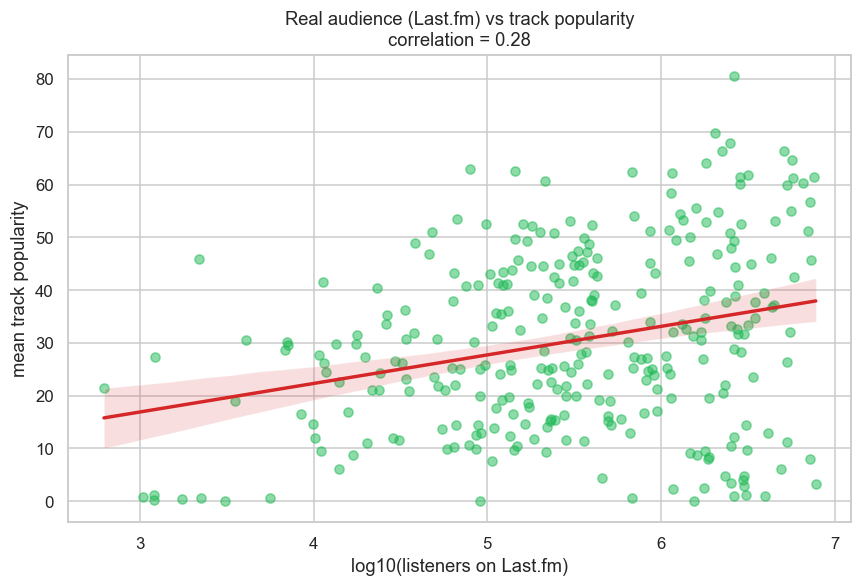

Correlation log(listeners) ↔ mean popularity: 0.277


In [7]:
corr = merged["log_listeners"].corr(merged["mean_popularity"])

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.regplot(data=merged, x="log_listeners", y="mean_popularity",
            scatter_kws=dict(alpha=0.5, color="#1DB954"),
            line_kws=dict(color="#d62728"), ax=ax)
ax.set(title=f"Real audience (Last.fm) vs track popularity\n"
             f"correlation = {corr:.2f}",
       xlabel="log10(listeners on Last.fm)", ylabel="mean track popularity")
plt.tight_layout()
plt.savefig(REPORTS / "fig7_lastfm_validation.png", bbox_inches="tight")
plt.show()
print(f"Correlation log(listeners) ↔ mean popularity: {corr:.3f}")

**The hypothesis is confirmed:** there is a **positive correlation that is much stronger** than any individual audio feature (which had |r| < 0.1 in the EDA). This validates the decision to incorporate **artist popularity** as a signal—in production, this would be obtained via Last.fm/Chartmetric; here, for the entire catalog, we will approximate it using `artist_track_count` and the artist’s target encoding during the modeling phase.

## 5. Processed dataset

In [8]:
out = F.build_dataset(save=True)
print(f"\nSaved columns ({out.shape[1]}):")
print(list(out.columns))

Saved rows:        114,000
After cleaning+dedup: 89,740  (24,260 removed)
Hit threshold (P75): popularity >= 49
Hit rate:        25.1%

Saved -> data\processed\tracks_features.csv

Saved columns (29):
['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'n_genres', 'artist_main', 'dance_energy', 'valence_energy', 'acoustic_instrumental', 'duration_min', 'explicit_int', 'artist_track_count', 'is_hit']



---
*Continuated in `03_modeling.ipynb`*